In [45]:
# =========================
# IMPROVED LSTM FOR KAGGLE STREAMFLOW
# =========================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# 1. LOAD FILES
# =========================

# Define the base path for the data files
data_path = '/content/drive/MyDrive/data_streamflow/'

df_train = pd.concat([
    pd.read_csv(data_path + 'trainTrackA.csv'),
    pd.read_csv(data_path + 'trainTrackB.csv')
]).reset_index(drop=True)

df_test = pd.concat([
    pd.read_csv(data_path + 'testTrackA.csv'),
    pd.read_csv(data_path + 'testTrackB.csv')
]).reset_index(drop=True)

example_sub = pd.read_csv(data_path + 'ExampleSubmission.csv')

df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

target_col = 'qobs_mm_per_hour'

# Use basin as group ID
group_col = 'basin'

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Example submission:", example_sub.shape)
print("Test starts:", df_test['date'].min())
print("Test ends:", df_test['date'].max())

Train shape: (490800, 55)
Test shape: (105120, 54)
Example submission: (52560, 5)
Test starts: 2017-01-01 00:00:00
Test ends: 2018-12-31 23:00:00


In [17]:
print(df_train.columns)

Index(['basin', 'date', 'longwave_radiation', 'potential_energy',
       'potential_evaporation', 'pressure', 'shortwave_radiation',
       'specific_humidity', 'temperature', 'total_precipitation', 'wind_u',
       'wind_v', 'qobs_mm_per_hour', 'geol_1st_class', 'glim_1st_class_frac',
       'geol_2nd_class', 'glim_2nd_class_frac', 'carbonate_rocks_frac',
       'geol_porostiy', 'geol_permeability', 'p_mean', 'pet_mean',
       'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq',
       'high_prec_dur', 'low_prec_freq', 'low_prec_dur',
       'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity',
       'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac',
       'clay_frac', 'water_frac', 'organic_frac', 'other_frac', 'gauge_lat',
       'gauge_lon', 'elev_mean', 'slope_mean', 'area_gages2',
       'area_geospa_fabric', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max',
       'gvf_diff', 'dom_land_cover_frac', 'dom_land_cover', 'root_depth_50',
       'root

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
# =========================
# 2. FEATURE ENGINEERING
# =========================

def add_time_features(df):
    df = df.copy()
    df['hour'] = df['date'].dt.hour
    df['dayofyear'] = df['date'].dt.dayofyear
    df['month'] = df['date'].dt.month

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    df['doy_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

    return df

df_train = add_time_features(df_train)
df_test = add_time_features(df_test)

# Clean data
df_train = df_train.sort_values([group_col, 'date']).reset_index(drop=True)
df_test = df_test.sort_values([group_col, 'date']).reset_index(drop=True)

df_train = df_train.ffill().bfill().fillna(0)
df_test = df_test.ffill().bfill().fillna(0)

# Remove invalid negative discharge
df_train[target_col] = df_train[target_col].clip(lower=0)

# Important: do NOT use target as feature
remove_cols = ['date', 'Unique_ID', 'basin', target_col]

features = [col for col in df_train.columns if col not in remove_cols]

# Keep only numeric features
features = df_train[features].select_dtypes(include=np.number).columns.tolist()

print("Number of features:", len(features))
print(features)

Number of features: 56
['longwave_radiation', 'potential_energy', 'potential_evaporation', 'pressure', 'shortwave_radiation', 'specific_humidity', 'temperature', 'total_precipitation', 'wind_u', 'wind_v', 'glim_1st_class_frac', 'glim_2nd_class_frac', 'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability', 'p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'water_frac', 'organic_frac', 'other_frac', 'gauge_lat', 'gauge_lon', 'elev_mean', 'slope_mean', 'area_gages2', 'area_geospa_fabric', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff', 'dom_land_cover_frac', 'root_depth_50', 'root_depth_99', 'hour', 'dayofyear', 'month', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


IMPROVEMENT 1 ADD LAGS

In [47]:
LAGS = [1, 2, 3, 6, 12, 24]

for lag in LAGS:
    df_train[f'lag_{lag}'] = df_train.groupby(group_col)[target_col].shift(lag)
    # Removed the line below as target_col is not present in df_test
    # df_test[f'lag_{lag}'] = df_test.groupby(group_col)[target_col].shift(lag)

df_train = df_train.ffill().bfill()
df_test = df_test.ffill().bfill()

IMPROVEMENT 2 ADD ROLLING FEATURES

In [48]:
# =========================
# ROLLING FEATURES (VERY POWERFUL)
# =========================

WINDOWS = [3, 6, 12, 24]

for w in WINDOWS:
    df_train[f'roll_mean_{w}'] = df_train.groupby(group_col)[target_col].rolling(w).mean().reset_index(0, drop=True)
    df_train[f'roll_std_{w}'] = df_train.groupby(group_col)[target_col].rolling(w).std().reset_index(0, drop=True)

df_train = df_train.ffill().bfill().fillna(0)

In [49]:
# =========================
# 3. SCALE DATA
# =========================

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

train_x_scaled = scaler_x.fit_transform(df_train[features])

# log1p helps streamflow because discharge has extreme peaks
train_y_log = np.log1p(df_train[[target_col]])
train_y_scaled = scaler_y.fit_transform(train_y_log)

df_train_scaled = df_train.copy()
df_train_scaled[features] = train_x_scaled
df_train_scaled[target_col] = train_y_scaled

df_test_scaled = df_test.copy()
df_test_scaled[features] = scaler_x.transform(df_test[features])

In [50]:
# =========================
# 4. CREATE SEQUENCES PER BASIN - RAM SAFE
# =========================

WINDOW_SIZE = 72
FORECAST_SIZE = 4
MAX_SAMPLES_PER_BASIN = 3000   # reduce if RAM still crashes

def create_sequences_by_basin(
    df,
    features,
    target_col,
    window_size=48,
    forecast_size=4,
    max_samples_per_basin=1200
):
    X, y = [], []

    for basin, g in df.groupby(group_col):
        g = g.sort_values('date').reset_index(drop=True)

        data_x = g[features].values.astype(np.float32)
        data_y = g[[target_col]].values.astype(np.float32)

        total_possible = len(g) - window_size - forecast_size + 1

        if total_possible <= 0:
            continue

        if total_possible > max_samples_per_basin:
            start_indices = np.linspace(
                0,
                total_possible - 1,
                max_samples_per_basin
            ).astype(int)
        else:
            start_indices = np.arange(total_possible)

        for i in start_indices:
            X.append(data_x[i:i + window_size])
            y.append(
                data_y[i + window_size:i + window_size + forecast_size].flatten()
            )

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = create_sequences_by_basin(
    df_train_scaled,
    features,
    target_col,
    WINDOW_SIZE,
    FORECAST_SIZE,
    MAX_SAMPLES_PER_BASIN
)

print("X shape:", X_all.shape)
print("y shape:", y_all.shape)

X shape: (18000, 72, 56)
y shape: (18000, 4)


In [51]:
# =========================
# 5. TRAIN / VALIDATION SPLIT
# =========================

split_idx = int(len(X_all) * 0.85)

X_train = X_all[:split_idx]
y_train = y_all[:split_idx]

X_val = X_all[split_idx:]
y_val = y_all[split_idx:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

Train: (15300, 72, 56) (15300, 4)
Validation: (2700, 72, 56) (2700, 4)


In [52]:
# =========================
# 6. IMPROVED LSTM MODEL
# =========================

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    Bidirectional(LSTM(128, return_sequences=True, activation='tanh')),
    Dropout(0.25),

    LSTM(64, return_sequences=False, activation='tanh'),
    Dropout(0.25),

    Dense(64, activation='relu'),
    Dropout(0.15),

    Dense(32, activation='relu'),
    Dense(FORECAST_SIZE)
])

optimizer = Adam(learning_rate=0.001, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss='mse', #IMPROVEMNET CHANGE THE LOSS FUNCTION
    metrics=['mae']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 72, 256)        │       189,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 72, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,988 (1.06 MB)

 Trainable params: 277,988 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# =========================
# 7. TRAIN MODEL
# =========================

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-5
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=128,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 5.6862e-04 - mae: 0.0110 - val_loss: 8.8417e-05 - val_mae: 0.0029 - learning_rate: 0.0010
Epoch 2/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 1.0631e-04 - mae: 0.0036 - val_loss: 9.0341e-05 - val_mae: 0.0033 - learning_rate: 0.0010
Epoch 3/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 1.0321e-04 - mae: 0.0034 - val_loss: 9.1483e-05 - val_mae: 0.0035 - learning_rate: 0.0010
Epoch 4/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1.0258e-04 - mae: 0.0033 - val_loss: 9.1673e-05 - val_mae: 0.0035 - learning_rate: 0.0010
Epoch 5/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 1.0209e-04 - mae: 0.0033 - val_loss: 9.2236e-05 - val_mae: 0.0036 - learning_rate: 0.0010
Epoch 6/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 1.0196e-04 - mae: 0.0033 - val_loss: 9.0113e-05 - val_mae: 0.0033 - learning_rate: 5.0000e-04
Epoch 7/80
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 1.0187e-04 - mae: 0.0032 - va

In [54]:
# =========================
# 8. PREDICT TEST DATA PER GAUGE_ID
# =========================

all_results = []

for gauge_id, gauge_df in df_test_scaled.groupby(group_col):

    gauge_df = gauge_df.sort_values('date').reset_index(drop=True)

    data_x = gauge_df[features].values.astype(np.float32)

    if len(gauge_df) < WINDOW_SIZE:
        continue

    X_test_gauge = []
    pred_dates = []
    pred_gauge_ids = []

    for i in range(len(gauge_df) - WINDOW_SIZE + 1):
        X_test_gauge.append(data_x[i:i + WINDOW_SIZE])
        pred_dates.append(gauge_df['date'].iloc[i + WINDOW_SIZE - 1])
        pred_gauge_ids.append(gauge_df[group_col].iloc[i + WINDOW_SIZE - 1])

    X_test_gauge = np.array(X_test_gauge, dtype=np.float32)

    preds_scaled = model.predict(X_test_gauge, batch_size=256, verbose=0)

    preds_log = scaler_y.inverse_transform(preds_scaled)
    preds_actual = np.expm1(preds_log)
    preds_actual = np.clip(preds_actual, 0, None)

    res = pd.DataFrame(
        preds_actual,
        columns=['Q_pred_t', 'Q_pred_t1', 'Q_pred_t2', 'Q_pred_t3']
    )

    res['date'] = pred_dates
    res['gauge_id'] = pred_gauge_ids

    res['gauge_id_str'] = res['gauge_id'].astype(int).astype(str).str.zfill(8)

    res['Unique_ID'] = (
        res['date'].dt.strftime('%Y-%m-%d %H:%M:%S')
        + '_'
        + res['gauge_id_str']
    )

    all_results.append(
        res[['Unique_ID', 'Q_pred_t', 'Q_pred_t1', 'Q_pred_t2', 'Q_pred_t3']]
    )

final_preds_df = pd.concat(all_results).reset_index(drop=True)

print(final_preds_df.head())
print(final_preds_df.tail())
print("Prediction shape:", final_preds_df.shape)

                      Unique_ID  Q_pred_t  Q_pred_t1  Q_pred_t2  Q_pred_t3
0  2017-01-03 23:00:00_08178880  0.008698   0.007972   0.007118   0.009744
1  2017-01-04 00:00:00_08178880  0.008650   0.008018   0.007085   0.009655
2  2017-01-04 01:00:00_08178880  0.008288   0.008358   0.006834   0.008982
3  2017-01-04 02:00:00_08178880  0.007855   0.008766   0.006534   0.008178
4  2017-01-04 03:00:00_08178880  0.007682   0.008929   0.006413   0.007855
                           Unique_ID  Q_pred_t  Q_pred_t1  Q_pred_t2  \
104689  2018-12-31 19:00:00_08202700  0.009670   0.007057   0.007793   
104690  2018-12-31 20:00:00_08202700  0.009841   0.006897   0.007911   
104691  2018-12-31 21:00:00_08202700  0.009893   0.006848   0.007948   
104692  2018-12-31 22:00:00_08202700  0.009893   0.006848   0.007948   
104693  2018-12-31 23:00:00_08202700  0.009893   0.006848   0.007948   

        Q_pred_t3  
104689   0.011554  
104690   0.011872  
104691   0.011970  
104692   0.011970  
104693   0.011970

In [55]:
# =========================
# 9. CREATE FINAL SUBMISSION
# =========================

required_cols = ['Unique_ID', 'Q_pred_t', 'Q_pred_t1', 'Q_pred_t2', 'Q_pred_t3']

submission = example_sub[['Unique_ID']].copy()

submission = submission.merge(
    final_preds_df[required_cols],
    on='Unique_ID',
    how='left'
)

print("Missing before fill:")
print(submission.isna().sum())

for col in ['Q_pred_t', 'Q_pred_t1', 'Q_pred_t2', 'Q_pred_t3']:
    median_value = final_preds_df[col].median()
    submission[col] = submission[col].fillna(median_value)
    submission[col] = submission[col].clip(lower=0)

# =========================
# 🔥 IMPORTANT: sort before smoothing
# =========================
submission = submission.sort_values('Unique_ID').reset_index(drop=True)

# =========================
# 🔥 IMPROVEMENT 3 (SMOOTHING)
# =========================
for col in ['Q_pred_t', 'Q_pred_t1', 'Q_pred_t2', 'Q_pred_t3']:
    submission[col] = (
        0.7 * submission[col] +
        0.3 * submission[col].rolling(3, min_periods=1).mean()
    )

# =========================
# FINALIZE
# =========================
submission = submission[required_cols]

submission.to_csv('submission_lstm_final.csv', index=False)

print("Saved: submission_lstm_final.csv")
print("Rows:", len(submission))
print(submission.head())
print(submission.tail())
print(submission.isna().sum())

from google.colab import files
files.download('submission_lstm_final.csv')

Missing before fill:
Unique_ID    0
Q_pred_t     0
Q_pred_t1    0
Q_pred_t2    0
Q_pred_t3    0
dtype: int64
Saved: submission_lstm_final.csv
Rows: 52560
                      Unique_ID  Q_pred_t  Q_pred_t1  Q_pred_t2  Q_pred_t3
0  2018-01-01 00:00:00_08178880  0.007003   0.009361   0.006334   0.006972
1  2018-01-01 00:00:00_08195000  0.008319   0.008298   0.006914   0.009097
2  2018-01-01 00:00:00_08196000  0.007542   0.009460   0.006219   0.007051
3  2018-01-01 00:00:00_08198500  0.007492   0.009448   0.006126   0.007019
4  2018-01-01 00:00:00_08200000  0.007632   0.009065   0.006344   0.007638
                          Unique_ID  Q_pred_t  Q_pred_t1  Q_pred_t2  Q_pred_t3
52555  2018-12-31 23:00:00_08195000  0.008280   0.008358   0.006844   0.008982
52556  2018-12-31 23:00:00_08196000  0.007492   0.009469   0.006160   0.007002
52557  2018-12-31 23:00:00_08198500  0.007387   0.009452   0.006051   0.006948
52558  2018-12-31 23:00:00_08200000  0.007694   0.008989   0.006387   0.007777
5

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CHECK OUTPUT

In [56]:
print("Matched IDs:")
print(final_preds_df['Unique_ID'].isin(example_sub['Unique_ID']).sum())

print(final_preds_df.describe())
print(final_preds_df.head())
print(final_preds_df.tail())

Matched IDs:
52560
            Q_pred_t      Q_pred_t1      Q_pred_t2      Q_pred_t3
count  104694.000000  104694.000000  104694.000000  104694.000000
mean        0.008025       0.008925       0.006599       0.008065
std         0.000837       0.000919       0.000688       0.001625
min         0.004969       0.006848       0.003442       0.005226
25%         0.007449       0.008280       0.006113       0.006769
50%         0.007863       0.009221       0.006440       0.007314
75%         0.008523       0.009657       0.007063       0.009128
max         0.011496       0.011040       0.009462       0.011970
                      Unique_ID  Q_pred_t  Q_pred_t1  Q_pred_t2  Q_pred_t3
0  2017-01-03 23:00:00_08178880  0.008698   0.007972   0.007118   0.009744
1  2017-01-04 00:00:00_08178880  0.008650   0.008018   0.007085   0.009655
2  2017-01-04 01:00:00_08178880  0.008288   0.008358   0.006834   0.008982
3  2017-01-04 02:00:00_08178880  0.007855   0.008766   0.006534   0.008178
4  2017-01-0

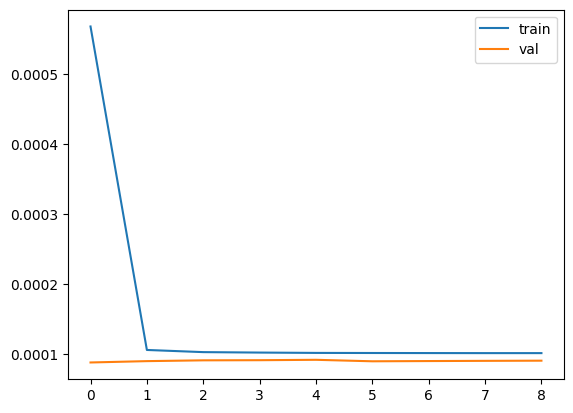

In [57]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

In [44]:
print(preds_scaled[:5])

[[0.00045266 0.00047282 0.00048312 0.00046477]
 [0.00045266 0.00047282 0.00048312 0.00046477]
 [0.00045266 0.00047282 0.00048312 0.00046477]
 [0.00045266 0.00047282 0.00048312 0.00046477]
 [0.00045266 0.00047282 0.00048312 0.00046477]]
